## AirFly Insights: Route, Cancellation and Seasonal Insights (Milestone3)

### Route, Airport-Level, Seasonal and Cancellation Analysis:-

In [1]:
#Importing all the libraries:-
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
#As the datatypes are not saved for the cleaned dataset in Python, :.Creating a use_datatypes funtion:-
def use_datatypes(df):
    data['FL_DATE']=pd.to_datetime(data['FL_DATE'])
    data['CANCELLED']=data['CANCELLED'].astype('int8')
    data['DIVERTED']=data['DIVERTED'].astype('int8')
    catg_col=['AIRLINE','AIRLINE_DOT','AIRLINE_CODE','ORIGIN','ORIGIN_CITY','DEST','DEST_CITY','CANCELLATION_CODE']
    for col in catg_col:
        data[col]=data[col].astype('category')
    minu_col=['DEP_DELAY','ARR_DELAY','TAXI_IN','TAXI_OUT','CRS_ELAPSED_TIME','ELAPSED_TIME','AIR_TIME','DELAY_DUE_CARRIER','DELAY_DUE_WEATHER','DELAY_DUE_NAS','DELAY_DUE_SECURITY','DELAY_DUE_LATE_AIRCRAFT']
    for col in minu_col:
        data[col]=data[col].astype('float32')
    hhmm_col=['CRS_DEP_TIME','DEP_TIME','CRS_ARR_TIME','ARR_TIME','WHEELS_OFF','WHEELS_ON']
    for col in hhmm_col:
        data[col]=data[col].astype('Int32')
    data['DISTANCE']=data['DISTANCE'].astype('float32')
    data['DOT_CODE']=data['DOT_CODE'].astype('int32')
    data['FL_NUMBER']=data['FL_NUMBER'].astype('int32')
    data['DEP_HOUR']=data['DEP_HOUR'].astype('Int8')
    data['ROUTE']=data['ROUTE'].astype('category')
    data['YEAR']=data['YEAR'].astype('int32')
    data['MONTH']=data['MONTH'].astype('int8')
    data['MONTH_NAME']=data['MONTH_NAME'].astype('category')
    data['WEEKDAY']=data['WEEKDAY'].astype('category')
    return df

In [3]:
data=pd.read_csv('cleaned_flights_sample.csv')
data.head()

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT,YEAR,MONTH,MONTH_NAME,WEEKDAY,DEP_HOUR,ROUTE
0,2019-01-09,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,1562,FLL,"Fort Lauderdale, FL",EWR,"Newark, NJ",...,0.0,0.0,0.0,0.0,2019,1,January,Wednesday,11,FLL-EWR
1,2022-11-19,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,1149,MSP,"Minneapolis, MN",SEA,"Seattle, WA",...,0.0,0.0,0.0,0.0,2022,11,November,Saturday,21,MSP-SEA
2,2022-07-22,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,459,DEN,"Denver, CO",MSP,"Minneapolis, MN",...,0.0,0.0,0.0,0.0,2022,7,July,Friday,10,DEN-MSP
3,2023-03-06,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2295,MSP,"Minneapolis, MN",SFO,"San Francisco, CA",...,0.0,24.0,0.0,0.0,2023,3,March,Monday,16,MSP-SFO
4,2020-02-23,Spirit Air Lines,Spirit Air Lines: NK,NK,20416,407,MCO,"Orlando, FL",DFW,"Dallas/Fort Worth, TX",...,0.0,0.0,0.0,0.0,2020,2,February,Sunday,18,MCO-DFW


In [4]:
data=use_datatypes(data)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2999984 entries, 0 to 2999983
Data columns (total 38 columns):
 #   Column                   Dtype         
---  ------                   -----         
 0   FL_DATE                  datetime64[ns]
 1   AIRLINE                  category      
 2   AIRLINE_DOT              category      
 3   AIRLINE_CODE             category      
 4   DOT_CODE                 int32         
 5   FL_NUMBER                int32         
 6   ORIGIN                   category      
 7   ORIGIN_CITY              category      
 8   DEST                     category      
 9   DEST_CITY                category      
 10  CRS_DEP_TIME             Int32         
 11  DEP_TIME                 Int32         
 12  DEP_DELAY                float32       
 13  TAXI_OUT                 float32       
 14  WHEELS_OFF               Int32         
 15  WHEELS_ON                Int32         
 16  TAXI_IN                  float32       
 17  CRS_ARR_TIME             In

In [6]:
#Analysing the flights which take off as well as they are not diverted, means they reach at their destination
active_flights=data[(data['CANCELLED']==0) & (data['DIVERTED']==0)]
len(active_flights)

2913802

#### Top-10 most Visited Routes (Origin-Destination pairs):-

In [7]:
active_flights['ROUTE']=active_flights['ROUTE'].astype('str')
top_dest=(active_flights['ROUTE'].value_counts().nlargest(10).reset_index())
top_dest.columns=['ROUTE','COUNT']
top_dest

,ROUTE,COUNT
0,SFO-LAX,5218
1,LAX-SFO,5072
2,OGG-HNL,4589
3,LAX-LAS,4540
4,LGA-ORD,4510
5,HNL-OGG,4489
6,LAS-LAX,4453
7,ORD-LGA,4403
8,LAX-JFK,4325
9,JFK-LAX,4232


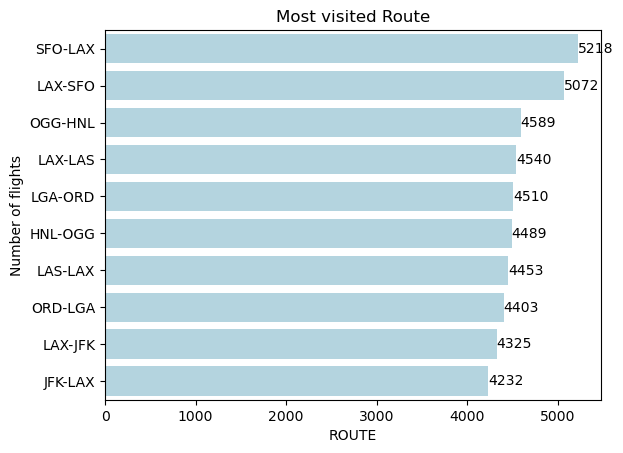

These are the Top 10 Routes visited.


In [8]:
i=sns.barplot(x='COUNT',y='ROUTE',data=top_dest,color='lightblue')
for bars in i.containers:
    i.bar_label(bars)
plt.xlabel('ROUTE')
plt.ylabel('Number of flights')
plt.title('Most visited Route')
plt.show()
print('These are the Top 10 Routes visited.')

### Top-10 most Delayed Routes:-

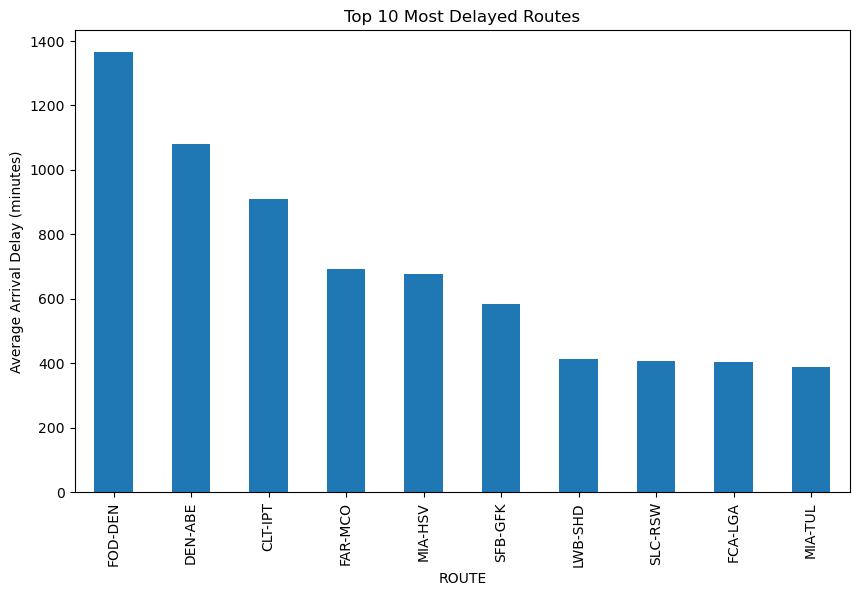

In [9]:
delayed_flights=active_flights[active_flights['ARR_DELAY']>0]  #The delayed flights, arr_delay>0
route_delay = delayed_flights.groupby('ROUTE')['ARR_DELAY'].mean().sort_values(ascending=False)

route_delay.head(10).plot(kind='bar', figsize=(10,6))
plt.title('Top 10 Most Delayed Routes')
plt.ylabel('Average Arrival Delay (minutes)')
plt.show()


### Top-10 Delayed Routes with Delayed Reasons:-

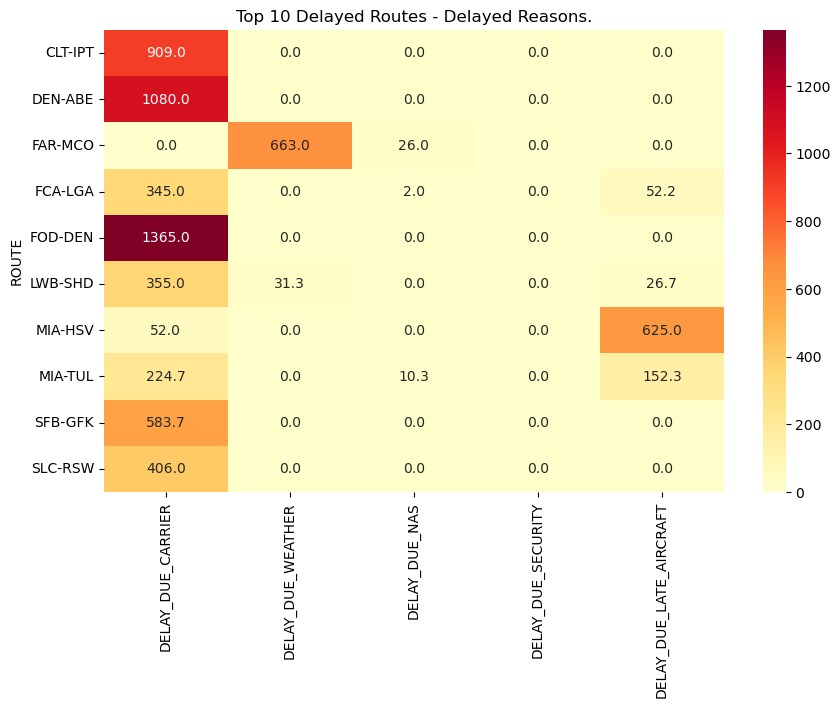

Top 10 Delayed routes with delayed reasons, FOD-DEN, DEN-ABE,CLT-IPT are the Routes with maximum delay_due_carrier, FAR-MCO route was delayed cause of weather.


In [10]:
top_routes = route_delay.head(10).index
top_delayed_data = delayed_flights[delayed_flights['ROUTE'].isin(top_routes)]
delay_reason_airline=top_delayed_data.groupby('ROUTE',observed=True)[['DELAY_DUE_CARRIER','DELAY_DUE_WEATHER','DELAY_DUE_NAS','DELAY_DUE_SECURITY','DELAY_DUE_LATE_AIRCRAFT']].mean()
plt.figure(figsize=(10,6))
sns.heatmap(delay_reason_airline,cmap='YlOrRd',annot=True,fmt='.1f')
plt.title('Top 10 Delayed Routes - Delayed Reasons.')
plt.show()
print('Top 10 Delayed routes with delayed reasons, FOD-DEN, DEN-ABE,CLT-IPT are the Routes with maximum delay_due_carrier, FAR-MCO route was delayed cause of weather.')

### Bussiest Airports (Origin based Airports):-

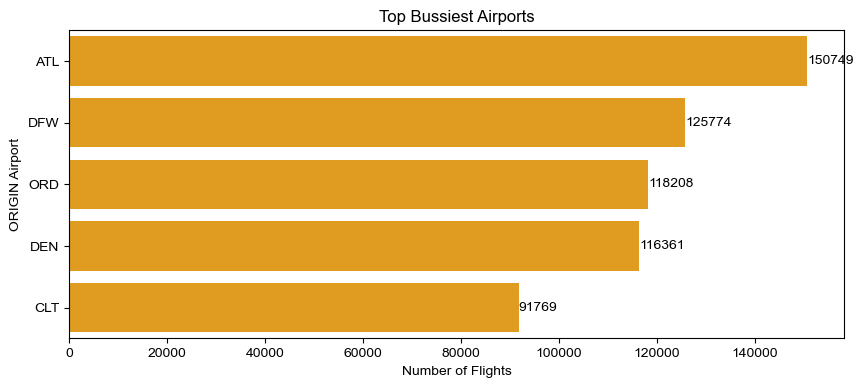

Above chart shows the bussiest Origin Airports.


In [11]:
top_airports=active_flights['ORIGIN'].value_counts().head(5)
plt.figure(figsize=(10,4))
i=sns.barplot(x=top_airports.values,y=top_airports.index,order=top_airports.index,color='orange')
for bars in i.containers:
    i.bar_label(bars)
plt.xlabel('Number of Flights')
plt.ylabel('ORIGIN Airport')
plt.title('Top Bussiest Airports')
sns.set_style('white')
plt.show()
print('Above chart shows the bussiest Origin Airports.')

### Average Departure and Arrival Delay by Airlines:-

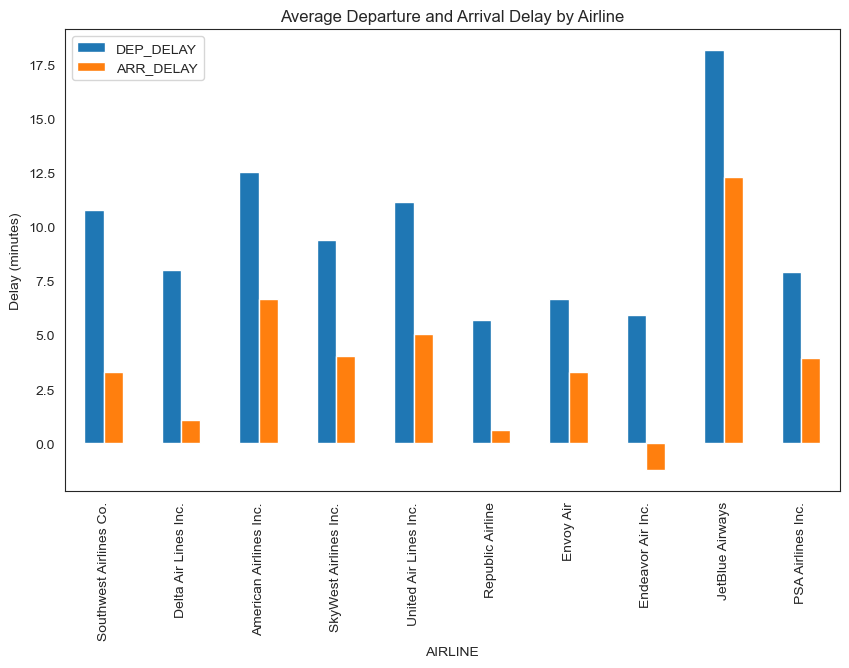

Avg DEP_DELAY is greater than ARR_DELAY. So, flights depart late but arrive with less delay which means airlines try to make up the time during journey.


In [12]:
airline_delay = active_flights.groupby('AIRLINE').agg({
    'DEP_DELAY': 'mean',
    'ARR_DELAY': 'mean'
}).sort_values('ARR_DELAY', ascending=False)

top_airlines = active_flights['AIRLINE'].value_counts().head(10).index
airline_delay_top = airline_delay.loc[top_airlines]

airline_delay_top.plot(kind='bar', figsize=(10,6))
plt.title('Average Departure and Arrival Delay by Airline')
plt.ylabel('Delay (minutes)')
plt.show()
print('Avg DEP_DELAY is greater than ARR_DELAY. So, flights depart late but arrive with less delay which means airlines try to make up the time during journey.')

In [13]:
#Cancelled flights:-
cancelled_flights=data[data['CANCELLED']==True]
len(cancelled_flights)

79126

### Average Cancellation of Flights by Month:-

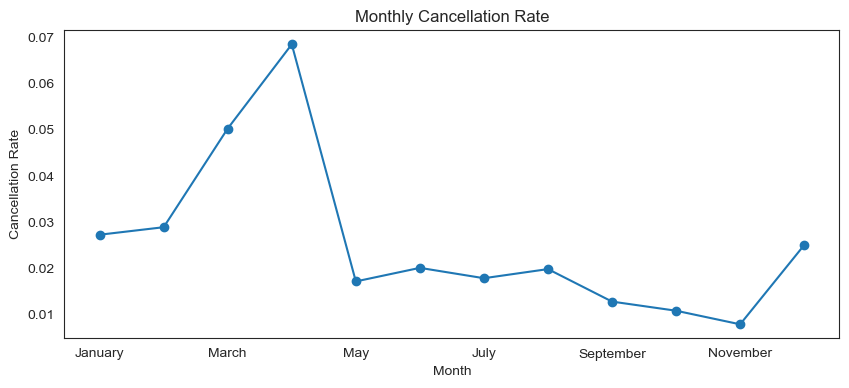

The flights cancellation rate is maximum in March and April and less in the month of November


In [14]:
#Avg Cancellation of flights in each month
month_order=['January','February','March','April','May','June','July','August','September','October','November','December']
monthly_count=data.groupby('MONTH_NAME')['CANCELLED'].mean().reindex(month_order)

plt.figure(figsize=(10,4))
monthly_count.plot(kind='line',marker='o')
plt.title('Monthly Cancellation Rate')
plt.xlabel('Month')
plt.ylabel('Cancellation Rate')
plt.show()

print('The flights cancellation rate is maximum in March and April and less in the month of November')

### Cancellation Types for Cancelled flights:-

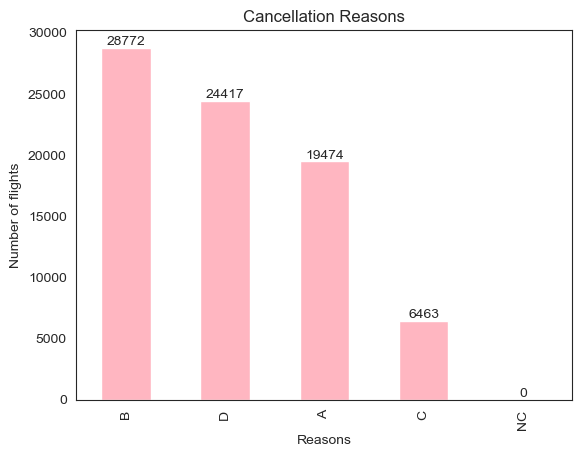

Here, A=Carrier, B=Weather, C=NAS, D=Security and NC is Not Cancelled. So, most of the flights got cancelled due to the Weather issues and Security issues.


In [15]:
#Cancellation types:-
cancel_types=cancelled_flights['CANCELLATION_CODE'].value_counts()
i=cancel_types.plot(kind='bar',color='lightpink')
for bars in i.containers:
    i.bar_label(bars)
plt.title('Cancellation Reasons')
plt.xlabel('Reasons')
plt.ylabel('Number of flights')
plt.show()

print('Here, A=Carrier, B=Weather, C=NAS, D=Security and NC is Not Cancelled. So, most of the flights got cancelled due to the Weather issues and Security issues.' )

### Impact of Holidays in the Month of Novermber and December:-

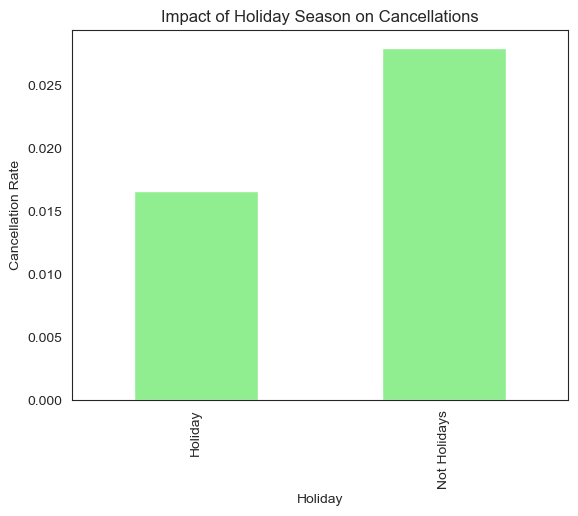

From the above chart, the cancellation rates during the holiday months are lower than the not holidays.


In [16]:
data['Holiday']=data['MONTH'].apply(lambda x: 'Holiday' if x in [11,12] else 'Not Holidays')
holiday_impact=data.groupby('Holiday')['CANCELLED'].mean()
holiday_impact.plot(kind='bar',color='lightgreen')
plt.title('Impact of Holiday Season on Cancellations')
plt.ylabel('Cancellation Rate')
plt.show()
print('From the above chart, the cancellation rates during the holiday months are lower than the not holidays.')